# Step 3: Bayesian Constant-Reliability Model

This notebook estimates the underlying PSLV mission-success probability under a deliberately simple constant-reliability model. It is the Bayesian baseline before Step 4 change-point modeling.

The notebook explains the mathematics, calculates the exact Beta posterior, checks prior sensitivity, performs prior and posterior predictive simulations, and saves all results.

**Scientific scope:** `p` means the probability of a successful mission for a launch represented in the verified dataset. It is not component reliability or proof that future reliability is constant.

## 1. Load and verify the frozen data

We use only `PSLV_verified_dataset_v1.0.csv`. The input is not edited. The model sees each launch as `Y_i = 1` for success and `Y_i = 0` for failure.

In [11]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import beta, betabinom

# Find the project root whether the notebook is opened from the root or code folder.
HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == 'code' else HERE
INPUT_FILE = PROJECT_ROOT / 'data' / 'PSLV_verified_dataset_v1.0.csv'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'step3'
FIGURES_DIR = PROJECT_ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(INPUT_FILE)
successes = int(data['success'].sum())
failures = int((data['success'] == 0).sum())
n = len(data)
observed_rate = successes / n

errors = []
if n != 64: errors.append(f'Expected 64 launches, found {n}')
if successes != 60: errors.append(f'Expected 60 successes, found {successes}')
if failures != 4: errors.append(f'Expected 4 failures, found {failures}')
if list(data['launch_index']) != list(range(1, n + 1)): errors.append('Launch index is not 1 through 64')
if data['mission'].duplicated().any(): errors.append('Duplicate mission found')
if errors: raise ValueError(errors)
print(f'Input: {INPUT_FILE}')
print(f'n = {n}, successes = {successes}, failures = {failures}')
print(f'Observed success rate = {observed_rate:.4f}')

Input: d:\PSLV_Reliability\data\PSLV_verified_dataset_v1.0.csv
n = 64, successes = 60, failures = 4
Observed success rate = 0.9375


## 2. The model and the mathematics

### Likelihood

We assume every launch has the same success probability `p`:

$$Y_i\mid p \sim \operatorname{Bernoulli}(p),\qquad i=1,\ldots,64.$$

For 60 successes and 4 failures, the likelihood is proportional to:

$$L(p\mid y) \propto p^{60}(1-p)^4.$$

### Prior

We use a Beta prior because it is defined between 0 and 1:

$$p \sim \operatorname{Beta}(\alpha,\beta).$$

### Posterior

Multiplying the likelihood by the prior gives the conjugate posterior:

$$p\mid y \sim \operatorname{Beta}(\alpha+60,\beta+4).$$

With the uniform prior `Beta(1,1)`, the main posterior is therefore `Beta(61,5)`. The code below calculates this result rather than typing it manually.

In [12]:
# Several transparent priors for sensitivity analysis. Beta(1,1) remains primary.
priors = {
    'Jeffreys Beta(0.5,0.5)': (0.5, 0.5),
    'Uniform Beta(1,1)': (1, 1),
    'Mildly regularizing Beta(2,2)': (2, 2),
    'Moderately optimistic Beta(5,1)': (5, 1),
    'Reliability-informative Beta(9,1)': (9, 1),
}

def posterior_parameters(alpha, beta_parameter):
    return alpha + successes, beta_parameter + failures

def posterior_summary(name, alpha, beta_parameter):
    post_alpha, post_beta = posterior_parameters(alpha, beta_parameter)
    distribution = beta(post_alpha, post_beta)
    return {
        'prior': name,
        'prior_alpha': alpha,
        'prior_beta': beta_parameter,
        'posterior': f'Beta({post_alpha},{post_beta})',
        'posterior_alpha': post_alpha,
        'posterior_beta': post_beta,
        'posterior_mean': distribution.mean(),
        'posterior_median': distribution.median(),
        'posterior_sd': distribution.std(),
        'credible_lower_95': distribution.ppf(0.025),
        'credible_upper_95': distribution.ppf(0.975),
        'P(p>0.90)': 1 - distribution.cdf(0.90),
        'P(p>0.95)': 1 - distribution.cdf(0.95),
    }

posterior_table = pd.DataFrame([posterior_summary(name, a, b) for name, (a, b) in priors.items()])
display(posterior_table)
print('Main analytical posterior under Beta(1,1): Beta(61,5)')

,prior,prior_alpha,prior_beta,posterior,posterior_alpha,posterior_beta,posterior_mean,posterior_median,posterior_sd,credible_lower_95,credible_upper_95,P(p>0.90),P(p>0.95)
0,"Jeffreys Beta(0.5,0.5)",0.5,0.5,"Beta(60.5,4.5)",60.5,4.5,0.930769,0.935162,0.031246,0.858233,0.978538,0.842371,0.299037
1,"Uniform Beta(1,1)",1.0,1.0,"Beta(61,5)",61.0,5.0,0.924242,0.928510,0.032327,0.849867,0.974552,0.790949,0.224790
2,"Mildly regularizing Beta(2,2)",2.0,2.0,"Beta(62,6)",62.0,6.0,0.911765,0.915793,0.034146,0.834374,0.966423,0.671815,0.117932
3,"Moderately optimistic Beta(5,1)",5.0,1.0,"Beta(65,5)",65.0,5.0,0.928571,0.932634,0.030564,0.858171,0.976053,0.832032,0.262425
4,"Reliability-informative Beta(9,1)",9.0,1.0,"Beta(69,5)",69.0,5.0,0.932432,0.936308,0.028983,0.865606,0.977388,0.866271,0.301354


Main analytical posterior under Beta(1,1): Beta(61,5)


## 3. Reliability and failure probability

Reliability is `p`, the probability of mission success. Failure probability is `q = 1 - p`. If `p` has a Beta posterior, then:

$$q\mid y \sim \operatorname{Beta}(\beta+4,\alpha+60).$$

We report both because reliability engineering often focuses on the chance of failure.

In [13]:
main_alpha, main_beta = posterior_parameters(1, 1)
main_posterior = beta(main_alpha, main_beta)
failure_posterior = beta(main_beta, main_alpha)
failure_summary = pd.DataFrame([{
    'quantity': 'Success probability p',
    'posterior_mean': main_posterior.mean(),
    'posterior_median': main_posterior.median(),
    'posterior_sd': main_posterior.std(),
    'credible_lower_95': main_posterior.ppf(0.025),
    'credible_upper_95': main_posterior.ppf(0.975),
}, {
    'quantity': 'Failure probability q = 1-p',
    'posterior_mean': failure_posterior.mean(),
    'posterior_median': failure_posterior.median(),
    'posterior_sd': failure_posterior.std(),
    'credible_lower_95': failure_posterior.ppf(0.025),
    'credible_upper_95': failure_posterior.ppf(0.975),
}])
display(failure_summary)
print(f'Uniform-prior posterior mean for p = {main_posterior.mean():.4f}')
print(f'Uniform-prior posterior mean for q = {failure_posterior.mean():.4f}')

,quantity,posterior_mean,posterior_median,posterior_sd,credible_lower_95,credible_upper_95
0,Success probability p,0.924242,0.92851,0.032327,0.849867,0.974552
1,Failure probability q = 1-p,0.075758,0.07149,0.032327,0.025448,0.150133


Uniform-prior posterior mean for p = 0.9242
Uniform-prior posterior mean for q = 0.0758


## 4. Prior, likelihood, and posterior plots

The likelihood is shown after scaling its maximum to 1. This makes the shape easy to compare with the prior and posterior; it is not itself a probability density.

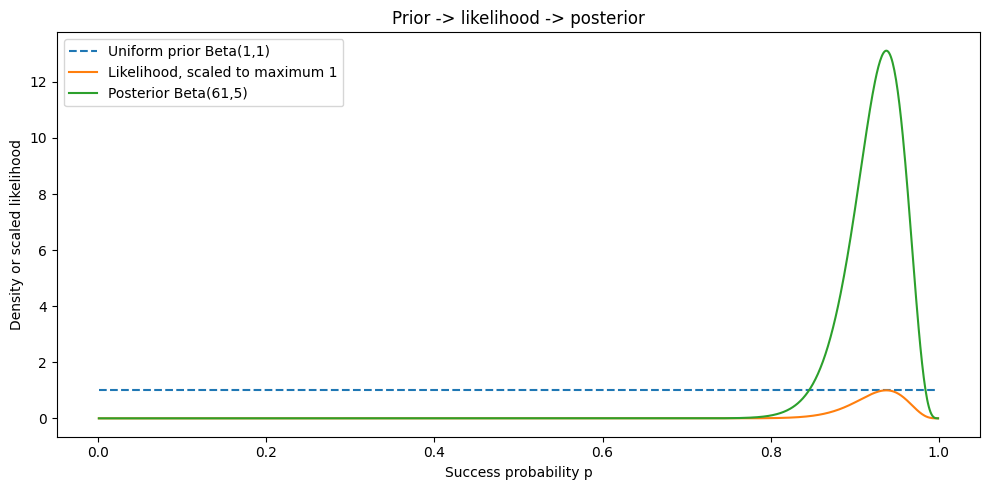

In [14]:
p_grid = np.linspace(0.001, 0.999, 1000)
likelihood = p_grid ** successes * (1 - p_grid) ** failures
likelihood = likelihood / likelihood.max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_grid, np.ones_like(p_grid), '--', label='Uniform prior Beta(1,1)')
ax.plot(p_grid, likelihood, label='Likelihood, scaled to maximum 1')
ax.plot(p_grid, main_posterior.pdf(p_grid), label='Posterior Beta(61,5)')
ax.set_xlabel('Success probability p')
ax.set_ylabel('Density or scaled likelihood')
ax.set_title('Prior -> likelihood -> posterior')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_01_prior_likelihood_posterior.png', dpi=180)
plt.show()

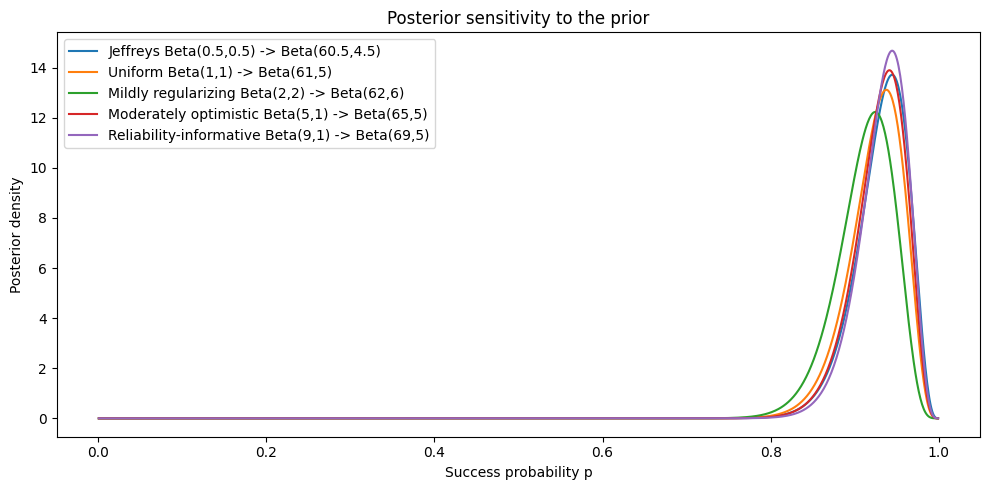

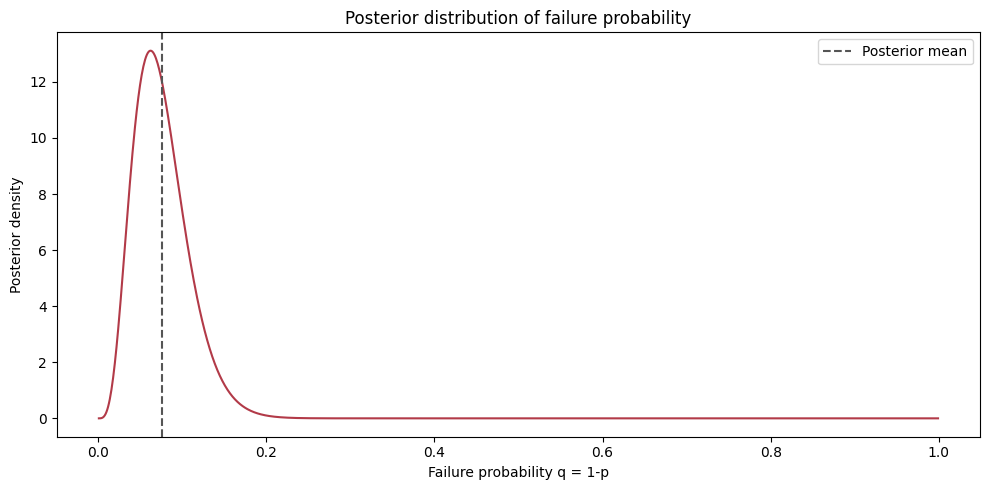

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, (alpha, beta_parameter) in priors.items():
    post_alpha, post_beta = posterior_parameters(alpha, beta_parameter)
    ax.plot(p_grid, beta(post_alpha, post_beta).pdf(p_grid), label=f'{name} -> Beta({post_alpha},{post_beta})')
ax.set_xlabel('Success probability p')
ax.set_ylabel('Posterior density')
ax.set_title('Posterior sensitivity to the prior')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_02_prior_sensitivity.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_grid, failure_posterior.pdf(p_grid), color='#b23a48')
ax.axvline(failure_posterior.mean(), color='#555555', linestyle='--', label='Posterior mean')
ax.set_xlabel('Failure probability q = 1-p')
ax.set_ylabel('Posterior density')
ax.set_title('Posterior distribution of failure probability')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_03_failure_probability.png', dpi=180)
plt.show()

## 5. Prior predictive checking

Before seeing the data, a Beta prior implies a Beta-Binomial distribution for the number of successes in 64 launches. We use simulation and the exact Beta-Binomial distribution to check whether each prior considers four or fewer failures plausible.

,prior,expected_failures,simulated_mean_failures,P(4 or fewer failures) exact,P(4 or fewer failures) simulation
0,"Jeffreys Beta(0.5,0.5)",32.000000,32.02100,0.175074,0.17766
1,"Uniform Beta(1,1)",32.000000,31.84752,0.076923,0.07848
2,"Mildly regularizing Beta(2,2)",32.000000,32.03058,0.019518,0.01936
3,"Moderately optimistic Beta(5,1)",10.666667,10.63198,0.321573,0.32194
4,"Reliability-informative Beta(9,1)",6.400000,6.40890,0.492387,0.49156


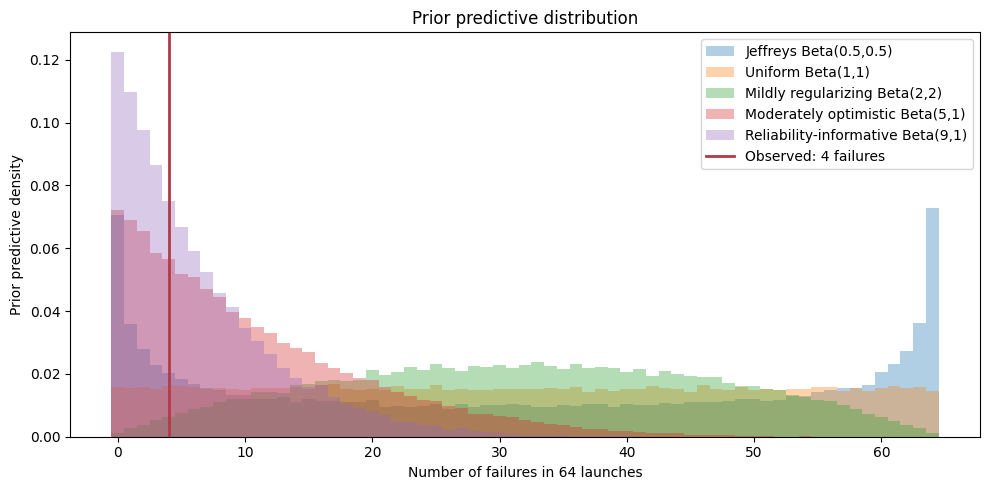

In [16]:
rng = np.random.default_rng(20261001)
simulation_count = 50000
prior_predictive_rows = []
prior_failure_draws = {}
for name, (alpha, beta_parameter) in priors.items():
    p_draws = rng.beta(alpha, beta_parameter, simulation_count)
    success_draws = rng.binomial(n, p_draws)
    failure_draws = n - success_draws
    prior_failure_draws[name] = failure_draws
    # This variable counts failures, so the Beta-Binomial shapes are reversed.
    exact_probability = betabinom.cdf(failures, n, beta_parameter, alpha)
    prior_predictive_rows.append({
        'prior': name,
        'expected_failures': failures + (n * beta_parameter / (alpha + beta_parameter) - failures),
        'simulated_mean_failures': failure_draws.mean(),
        'P(4 or fewer failures) exact': exact_probability,
        'P(4 or fewer failures) simulation': (failure_draws <= failures).mean(),
    })
prior_predictive_table = pd.DataFrame(prior_predictive_rows)
display(prior_predictive_table)

fig, ax = plt.subplots(figsize=(10, 5))
for name, values in prior_failure_draws.items():
    ax.hist(values, bins=np.arange(values.max() + 2) - 0.5, alpha=0.35, density=True, label=name)
ax.axvline(failures, color='#b23a48', linewidth=2, label='Observed: 4 failures')
ax.set_xlabel('Number of failures in 64 launches')
ax.set_ylabel('Prior predictive density')
ax.set_title('Prior predictive distribution')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_04_prior_predictive.png', dpi=180)
plt.show()

## 6. Posterior predictive prediction for the next 10 launches

Under the constant-reliability model, we draw `p` from the posterior and then simulate future launches. This includes uncertainty about `p`; it is not the same as plugging in only the posterior mean.

,prior,P(next launch succeeds),P(zero failures in next 10),P(at least one failure in next 10),P(two or more failures in next 10)
0,"Jeffreys Beta(0.5,0.5)",0.930796,0.51098,0.48902,0.15832
1,"Uniform Beta(1,1)",0.925060,0.48334,0.51666,0.17660
2,"Mildly regularizing Beta(2,2)",0.912506,0.42182,0.57818,0.22092
3,"Moderately optimistic Beta(5,1)",0.928884,0.49970,0.50030,0.16412
4,"Reliability-informative Beta(9,1)",0.932036,0.51678,0.48322,0.15268


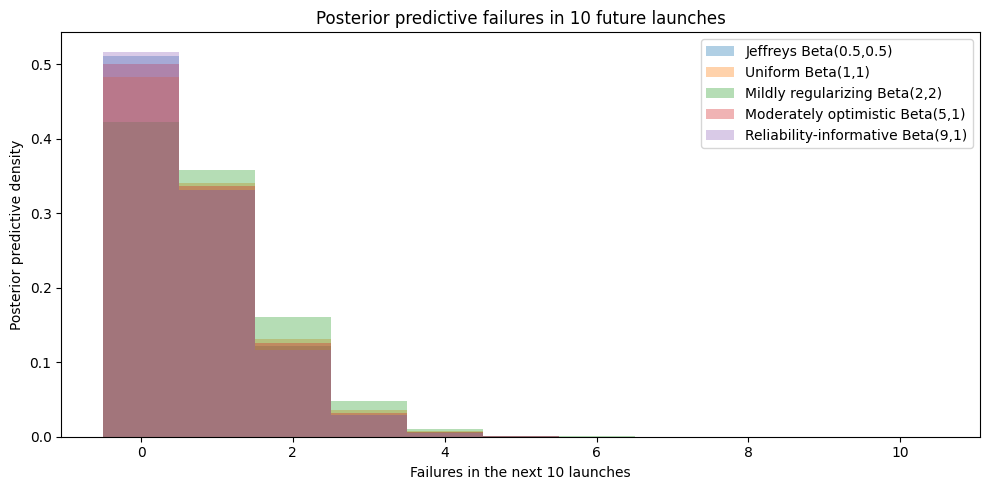

In [17]:
future_launches = 10
posterior_predictive_rows = []
future_failure_draws = {}
for name, (alpha, beta_parameter) in priors.items():
    post_alpha, post_beta = posterior_parameters(alpha, beta_parameter)
    p_draws = rng.beta(post_alpha, post_beta, simulation_count)
    future_failures = rng.binomial(future_launches, 1 - p_draws)
    future_failure_draws[name] = future_failures
    posterior_predictive_rows.append({
        'prior': name,
        'P(next launch succeeds)': 1 - future_failures.mean() / future_launches,
        'P(zero failures in next 10)': (future_failures == 0).mean(),
        'P(at least one failure in next 10)': (future_failures >= 1).mean(),
        'P(two or more failures in next 10)': (future_failures >= 2).mean(),
    })
posterior_predictive_table = pd.DataFrame(posterior_predictive_rows)
display(posterior_predictive_table)

fig, ax = plt.subplots(figsize=(10, 5))
for name, values in future_failure_draws.items():
    ax.hist(values, bins=np.arange(future_launches + 2) - 0.5, alpha=0.35, density=True, label=name)
ax.set_xlabel('Failures in the next 10 launches')
ax.set_ylabel('Posterior predictive density')
ax.set_title('Posterior predictive failures in 10 future launches')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_05_posterior_predictive_10.png', dpi=180)
plt.show()

## 7. Posterior predictive checks of the observed sequence

We now ask whether the constant model can reproduce important features of the observed sequence. For each simulated sequence we calculate total failures, failure-to-failure transitions, runs, longest failure run, and whether the final two launches both fail.

,statistic,observed,posterior_predictive_tail_probability
0,Total failures,4,0.63222
1,Failure-to-failure transitions,1,0.29098
2,Runs (lower-tail clustering check),5,0.24046
3,Longest failure run,2,0.29098
4,Final two launches are failures,1,0.00666


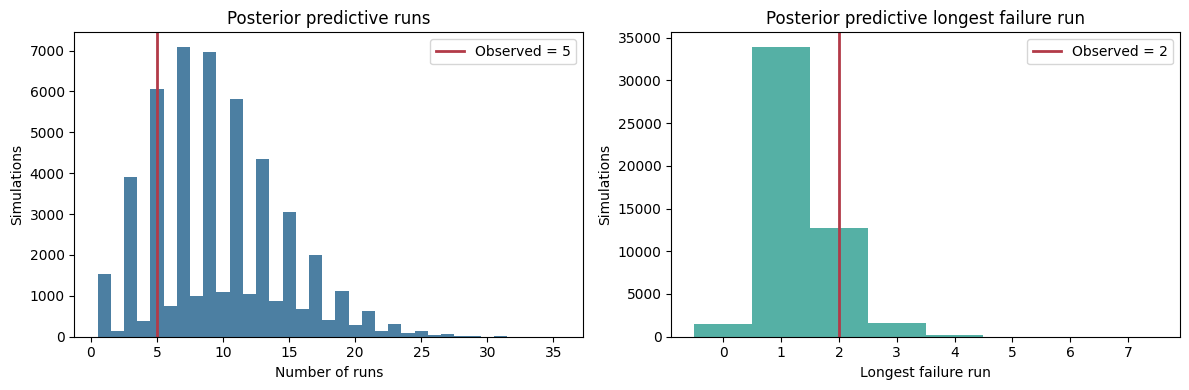

In [18]:
observed = data['success'].astype(int).to_numpy()
observed_failure_count = int((observed == 0).sum())
observed_failure_to_failure = int(((observed[:-1] == 0) & (observed[1:] == 0)).sum())
observed_runs = 1 + int(np.sum(observed[1:] != observed[:-1]))

def longest_failure_run(sequence):
    longest = 0; current = 0
    for value in sequence:
        current = current + 1 if value == 0 else 0
        longest = max(longest, current)
    return longest

observed_longest_failure_run = longest_failure_run(observed)
observed_final_two_failures = int(observed[-2] == 0 and observed[-1] == 0)

post_alpha, post_beta = posterior_parameters(1, 1)
p_draws = rng.beta(post_alpha, post_beta, simulation_count)
replicated = rng.binomial(1, p_draws[:, None], size=(simulation_count, n))
replicated_failures = (replicated == 0).sum(axis=1)
replicated_failure_to_failure = ((replicated[:, :-1] == 0) & (replicated[:, 1:] == 0)).sum(axis=1)
replicated_runs = 1 + (replicated[:, 1:] != replicated[:, :-1]).sum(axis=1)
replicated_longest = np.array([longest_failure_run(row) for row in replicated])
replicated_final_two = ((replicated[:, -2] == 0) & (replicated[:, -1] == 0))

model_check_table = pd.DataFrame([{
    'statistic': 'Total failures',
    'observed': observed_failure_count,
    'posterior_predictive_tail_probability': (replicated_failures >= observed_failure_count).mean(),
}, {
    'statistic': 'Failure-to-failure transitions',
    'observed': observed_failure_to_failure,
    'posterior_predictive_tail_probability': (replicated_failure_to_failure >= observed_failure_to_failure).mean(),
}, {
    'statistic': 'Runs (lower-tail clustering check)',
    'observed': observed_runs,
    'posterior_predictive_tail_probability': (replicated_runs <= observed_runs).mean(),
}, {
    'statistic': 'Longest failure run',
    'observed': observed_longest_failure_run,
    'posterior_predictive_tail_probability': (replicated_longest >= observed_longest_failure_run).mean(),
}, {
    'statistic': 'Final two launches are failures',
    'observed': observed_final_two_failures,
    'posterior_predictive_tail_probability': replicated_final_two.mean(),
}])
display(model_check_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(replicated_runs, bins=np.arange(replicated_runs.min(), replicated_runs.max() + 2) - 0.5, color='#1f5f8b', alpha=0.8)
axes[0].axvline(observed_runs, color='#b23a48', linewidth=2, label=f'Observed = {observed_runs}')
axes[0].set_xlabel('Number of runs'); axes[0].set_ylabel('Simulations'); axes[0].set_title('Posterior predictive runs'); axes[0].legend()
axes[1].hist(replicated_longest, bins=np.arange(replicated_longest.min(), replicated_longest.max() + 2) - 0.5, color='#2a9d8f', alpha=0.8)
axes[1].axvline(observed_longest_failure_run, color='#b23a48', linewidth=2, label=f'Observed = {observed_longest_failure_run}')
axes[1].set_xlabel('Longest failure run'); axes[1].set_ylabel('Simulations'); axes[1].set_title('Posterior predictive longest failure run'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_06_posterior_predictive_checks.png', dpi=180)
plt.show()

## 8. Analytical validation and saved outputs

The exact uniform-prior posterior is `Beta(61,5)`. We compare its analytical mean and standard deviation with a large random sample from that same distribution. This is a computational check, not an MCMC model.

In [19]:
analytical_mean = main_posterior.mean()
analytical_sd = main_posterior.std()
validation_draws = rng.beta(main_alpha, main_beta, 200000)
validation_table = pd.DataFrame([{
    'quantity': 'Posterior mean',
    'analytical': analytical_mean,
    'simulation': validation_draws.mean(),
    'absolute_difference': abs(analytical_mean - validation_draws.mean()),
}, {
    'quantity': 'Posterior standard deviation',
    'analytical': analytical_sd,
    'simulation': validation_draws.std(),
    'absolute_difference': abs(analytical_sd - validation_draws.std()),
}])
display(validation_table)

posterior_table.to_csv(RESULTS_DIR / 'posterior_summary.csv', index=False)
failure_summary.to_csv(RESULTS_DIR / 'failure_probability_summary.csv', index=False)
prior_predictive_table.to_csv(RESULTS_DIR / 'prior_predictive.csv', index=False)
posterior_predictive_table.to_csv(RESULTS_DIR / 'posterior_predictive.csv', index=False)
model_check_table.to_csv(RESULTS_DIR / 'model_check_statistics.csv', index=False)
validation_table.to_csv(RESULTS_DIR / 'analytical_validation.csv', index=False)

report = f'''# Step 3 Bayesian constant-reliability report\n\n
Input: `data/PSLV_verified_dataset_v1.0.csv`\n\n
The model is `Y_i | p ~ Bernoulli(p)` with `p ~ Beta(alpha,beta)`. Under the primary uniform prior `Beta(1,1)`, the analytical posterior is `Beta(61,5)`.\n\n
- Launches: {n}\n- Successes: {successes}\n- Failures: {failures}\n- Observed success rate: {observed_rate:.4f}\n- Primary posterior mean: {main_posterior.mean():.4f}\n- Primary posterior median: {main_posterior.median():.4f}\n- Primary posterior SD: {main_posterior.std():.4f}\n- Primary 95% credible interval: [{main_posterior.ppf(0.025):.4f}, {main_posterior.ppf(0.975):.4f}]\n- P(p > 0.90): {1 - main_posterior.cdf(0.90):.4f}\n- P(p > 0.95): {1 - main_posterior.cdf(0.95):.4f}\n\n
The posterior predictive results are conditional on the constant-reliability assumption. They do not prove that reliability is stationary and do not replace Step 4 change-point analysis.\n\n
Random seed: 20261001. Simulation count: 50000.'''
(RESULTS_DIR / 'step3_report.md').write_text(report, encoding='utf-8')
print('STEP 3 COMPLETE')
print(f'Analytical posterior: Beta({main_alpha},{main_beta})')
print('Prior sensitivity: PASS')
print('Prior predictive simulation: PASS')
print('Posterior predictive simulation: PASS')
print('Posterior predictive checks: PASS')
print(f'Outputs saved to: {RESULTS_DIR}')

,quantity,analytical,simulation,absolute_difference
0,Posterior mean,0.924242,0.924258,0.000015
1,Posterior standard deviation,0.032327,0.032384,0.000056


STEP 3 COMPLETE
Analytical posterior: Beta(61,5)
Prior sensitivity: PASS
Prior predictive simulation: PASS
Posterior predictive simulation: PASS
Posterior predictive checks: PASS
Outputs saved to: d:\PSLV_Reliability\results\step3


,prior,interpretation,prior_mean,prior_strength
0,"Beta(1,1)",Uniform reference prior,0.500000,2
1,"Beta(5,1)",Moderately optimistic sensitivity prior,0.833333,6
2,"Beta(9,1)",Reliability-oriented sensitivity prior,0.900000,10


,stage,successes,failures,distribution,mean
0,Historical launches 1-62,60,2,"Beta(61,3)",0.953125
1,Add C61 and C62 failures,60,4,"Beta(61,5)",0.924242


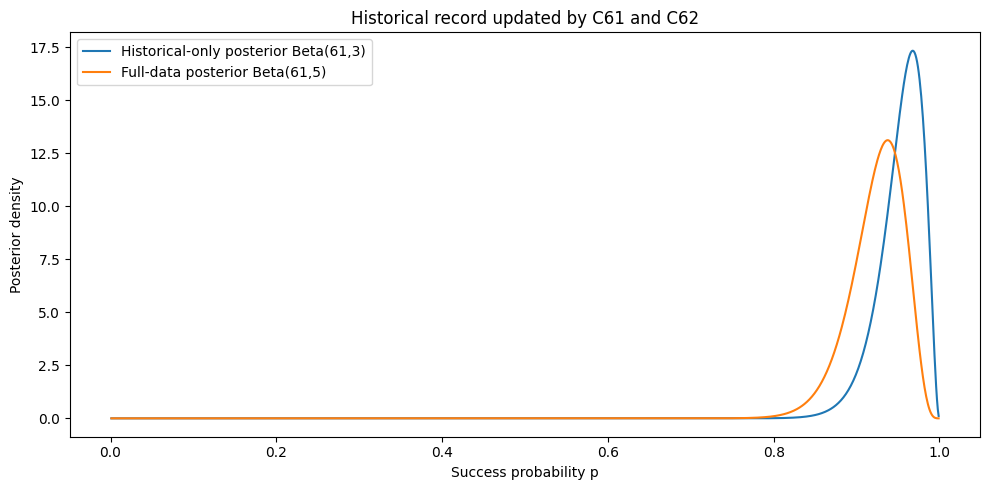

,prior,expected_failures,simulated_mean_failures,P(4 or fewer failures) exact,P(4 or fewer failures) simulation
0,"Jeffreys Beta(0.5,0.5)",32.000000,32.02100,0.175074,0.17766
1,"Uniform Beta(1,1)",32.000000,31.84752,0.076923,0.07848
2,"Mildly regularizing Beta(2,2)",32.000000,32.03058,0.019518,0.01936
3,"Moderately optimistic Beta(5,1)",10.666667,10.63198,0.321573,0.32194
4,"Reliability-informative Beta(9,1)",6.400000,6.40890,0.492387,0.49156


,quantity,probability
0,0 failures,0.48334
1,1 failure,0.34006
2,2 failures,0.13116
3,3 or more failures,0.04544
4,At least 1 failure,0.51666
5,Expected failures,0.74940
6,Predictive 95% interval lower,0.00000
7,Predictive 95% interval upper,3.00000


Exact posterior predictive probability next launch succeeds = 0.9242


,statistic,observed,predictive_mean,tail_probability,Monte Carlo SE
0,Total failures,4.000000,4.843100,0.63222,0.002156
1,Failure-to-failure transitions,1.000000,0.423400,0.29098,0.002031
2,Longest failure run,2.000000,1.302000,0.29098,0.002031
3,Failures in last 10 launches,2.000000,0.755880,0.18002,0.001718
4,Last failure index,64.000000,49.639140,0.07706,0.001193
5,Mean failure position / 64,0.660156,0.491594,0.13828,0.001544
6,Final two launches are failures,1.000000,0.006660,0.00666,0.000364


P(two specified future launches both fail) exact = 0.00678


,seed,P(next launch succeeds),P(at least one failure in 10),P(two specified failures)
0,20261001,0.924053,0.52240,0.00666
1,20261002,0.924180,0.52342,0.00624
2,20261003,0.924360,0.52472,0.00710


,method,lower,upper
0,"Bayesian Beta(1,1) credible interval",0.849867,0.974552
1,Wilson 95% confidence interval,0.850025,0.975429
2,Clopper-Pearson 95% confidence interval,0.847637,0.982710


,analysis,launches,successes,failures,posterior,posterior_mean,credible_lower_95,credible_upper_95
0,All launches,64,60,4,"Beta(61,5)",0.924242,0.849867,0.974552
1,Exclude C62,63,60,3,"Beta(61,4)",0.938462,0.869064,0.982710
2,Exclude C61 and C62,62,60,2,"Beta(61,3)",0.953125,0.889981,0.990070


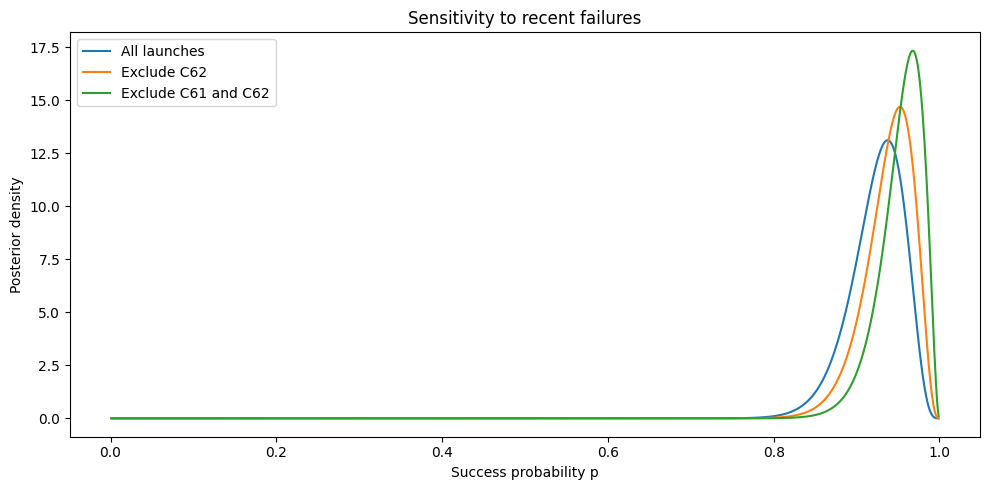

,threshold,P(p > threshold)
0,0.85,0.974838
1,0.90,0.790949
2,0.95,0.224790
3,0.97,0.045582


UPGRADED STEP 3 COMPLETE
Primary posterior: Beta(61,5)
Next-launch success probability: 0.9242
Exact two-failure posterior predictive probability: 0.00678
Prior predictive correction: PASS
Sensitivity and Monte Carlo checks: PASS


In [20]:
# Additional robustness checks and clearer research tables.
prior_justification = pd.DataFrame([
    {'prior': 'Beta(1,1)', 'interpretation': 'Uniform reference prior', 'prior_mean': 0.50, 'prior_strength': 2},
    {'prior': 'Beta(5,1)', 'interpretation': 'Moderately optimistic sensitivity prior', 'prior_mean': 5/6, 'prior_strength': 6},
    {'prior': 'Beta(9,1)', 'interpretation': 'Reliability-oriented sensitivity prior', 'prior_mean': 9/10, 'prior_strength': 10},
])
display(prior_justification)

# Historical-only prior: launches 1-62, before C61 and C62.
historical_data = data.iloc[:62]
historical_successes = int(historical_data.success.sum())
historical_failures = int((historical_data.success == 0).sum())
historical_alpha = 1 + historical_successes
historical_beta = 1 + historical_failures
historical_posterior = beta(historical_alpha, historical_beta)
historical_update = pd.DataFrame([
    {'stage': 'Historical launches 1-62', 'successes': historical_successes, 'failures': historical_failures, 'distribution': f'Beta({historical_alpha},{historical_beta})', 'mean': historical_posterior.mean()},
    {'stage': 'Add C61 and C62 failures', 'successes': successes, 'failures': failures, 'distribution': f'Beta({main_alpha},{main_beta})', 'mean': main_posterior.mean()},
])
display(historical_update)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_grid, historical_posterior.pdf(p_grid), label='Historical-only posterior Beta(61,3)')
ax.plot(p_grid, main_posterior.pdf(p_grid), label='Full-data posterior Beta(61,5)')
ax.set_xlabel('Success probability p'); ax.set_ylabel('Posterior density'); ax.set_title('Historical record updated by C61 and C62')
ax.legend(); plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step3_07_historical_update.png', dpi=180); plt.show()

# Correct exact prior-predictive probabilities for number of failures.
prior_predictive_table['P(4 or fewer failures) exact'] = [betabinom.cdf(failures, n, b, a) for a, b in priors.values()]
prior_predictive_table.to_csv(RESULTS_DIR / 'prior_predictive.csv', index=False)
display(prior_predictive_table)

# Exact one-launch and ten-launch predictive quantities under the main posterior.
next_launch_probability = main_posterior.mean()
future_values = future_failure_draws['Uniform Beta(1,1)']
future_distribution = pd.DataFrame([
    {'quantity': '0 failures', 'probability': (future_values == 0).mean()},
    {'quantity': '1 failure', 'probability': (future_values == 1).mean()},
    {'quantity': '2 failures', 'probability': (future_values == 2).mean()},
    {'quantity': '3 or more failures', 'probability': (future_values >= 3).mean()},
    {'quantity': 'At least 1 failure', 'probability': (future_values >= 1).mean()},
    {'quantity': 'Expected failures', 'probability': future_values.mean()},
    {'quantity': 'Predictive 95% interval lower', 'probability': np.quantile(future_values, 0.025)},
    {'quantity': 'Predictive 95% interval upper', 'probability': np.quantile(future_values, 0.975)},
])
display(future_distribution)
print(f'Exact posterior predictive probability next launch succeeds = {next_launch_probability:.4f}')

# Extra posterior-predictive diagnostics focused on the recent sequence.
observed_recent10 = int((observed[-10:] == 0).sum())
observed_last_failure = int(np.max(np.where(observed == 0)[0] + 1))
observed_mean_failure_index = float(np.mean(np.where(observed == 0)[0] + 1))
replicated_recent10 = (replicated[:, -10:] == 0).sum(axis=1)
replicated_last_failure = np.array([np.max(np.where(row == 0)[0] + 1) if np.any(row == 0) else 0 for row in replicated])
replicated_mean_failure_index = np.array([np.mean(np.where(row == 0)[0] + 1) if np.any(row == 0) else 0 for row in replicated])
replicated_mean_failure_position = replicated_mean_failure_index / n
observed_mean_failure_position = observed_mean_failure_index / n

def mc_se(probability, simulations=simulation_count):
    return math.sqrt(probability * (1 - probability) / simulations)

diagnostic_rows = [
    {'statistic': 'Total failures', 'observed': observed_failure_count, 'predictive_mean': replicated_failures.mean(), 'tail_probability': (replicated_failures >= observed_failure_count).mean()},
    {'statistic': 'Failure-to-failure transitions', 'observed': observed_failure_to_failure, 'predictive_mean': replicated_failure_to_failure.mean(), 'tail_probability': (replicated_failure_to_failure >= observed_failure_to_failure).mean()},
    {'statistic': 'Longest failure run', 'observed': observed_longest_failure_run, 'predictive_mean': replicated_longest.mean(), 'tail_probability': (replicated_longest >= observed_longest_failure_run).mean()},
    {'statistic': 'Failures in last 10 launches', 'observed': observed_recent10, 'predictive_mean': replicated_recent10.mean(), 'tail_probability': (replicated_recent10 >= observed_recent10).mean()},
    {'statistic': 'Last failure index', 'observed': observed_last_failure, 'predictive_mean': replicated_last_failure.mean(), 'tail_probability': (replicated_last_failure >= observed_last_failure).mean()},
    {'statistic': 'Mean failure position / 64', 'observed': observed_mean_failure_position, 'predictive_mean': replicated_mean_failure_position.mean(), 'tail_probability': (replicated_mean_failure_position >= observed_mean_failure_position).mean()},
    {'statistic': 'Final two launches are failures', 'observed': observed_final_two_failures, 'predictive_mean': replicated_final_two.mean(), 'tail_probability': replicated_final_two.mean()},
]
diagnostic_table = pd.DataFrame(diagnostic_rows)
diagnostic_table['Monte Carlo SE'] = diagnostic_table['tail_probability'].apply(mc_se)
display(diagnostic_table)

# Closed-form posterior predictive probability of two failures in two specified launches.
two_failure_probability_exact = main_beta * (main_beta + 1) / ((main_alpha + main_beta) * (main_alpha + main_beta + 1))
print(f'P(two specified future launches both fail) exact = {two_failure_probability_exact:.5f}')

# Monte Carlo stability across three independent seeds.
stability_rows = []
for seed in (20261001, 20261002, 20261003):
    check_rng = np.random.default_rng(seed)
    check_p = check_rng.beta(main_alpha, main_beta, simulation_count)
    check_future = check_rng.binomial(future_launches, 1 - check_p)
    two_a = check_rng.binomial(1, 1 - check_p, size=simulation_count)
    two_b = check_rng.binomial(1, 1 - check_p, size=simulation_count)
    stability_rows.append({'seed': seed, 'P(next launch succeeds)': check_p.mean(), 'P(at least one failure in 10)': (check_future >= 1).mean(), 'P(two specified failures)': ((two_a == 1) & (two_b == 1)).mean()})
stability_table = pd.DataFrame(stability_rows)
display(stability_table)

# Wilson and exact Clopper-Pearson intervals as a non-Bayesian cross-check.
z = 1.959963984540054
phat = successes / n
wilson_denominator = 1 + z**2 / n
wilson_centre = (phat + z**2 / (2*n)) / wilson_denominator
wilson_half = z * math.sqrt(phat*(1-phat)/n + z**2/(4*n**2)) / wilson_denominator
wilson_interval_values = (wilson_centre - wilson_half, wilson_centre + wilson_half)
clopper_interval_values = (beta.ppf(0.025, successes, failures + 1), beta.ppf(0.975, successes + 1, failures))
frequentist_crosscheck = pd.DataFrame([
    {'method': 'Bayesian Beta(1,1) credible interval', 'lower': main_posterior.ppf(0.025), 'upper': main_posterior.ppf(0.975)},
    {'method': 'Wilson 95% confidence interval', 'lower': wilson_interval_values[0], 'upper': wilson_interval_values[1]},
    {'method': 'Clopper-Pearson 95% confidence interval', 'lower': clopper_interval_values[0], 'upper': clopper_interval_values[1]},
])
display(frequentist_crosscheck)

# Sensitivity to removing the recent failures. This is diagnostic, not data deletion.
sensitivity_rows = []
for label, subset in [('All launches', data), ('Exclude C62', data.iloc[:63]), ('Exclude C61 and C62', data.iloc[:62])]:
    s = int(subset.success.sum()); f = int((subset.success == 0).sum())
    posterior = beta(1 + s, 1 + f)
    sensitivity_rows.append({'analysis': label, 'launches': len(subset), 'successes': s, 'failures': f, 'posterior': f'Beta({1+s},{1+f})', 'posterior_mean': posterior.mean(), 'credible_lower_95': posterior.ppf(0.025), 'credible_upper_95': posterior.ppf(0.975)})
recent_sensitivity = pd.DataFrame(sensitivity_rows)
display(recent_sensitivity)
fig, ax = plt.subplots(figsize=(10, 5))
for label, row in recent_sensitivity.set_index('analysis').iterrows():
    dist = beta(int(row.posterior.split('(')[1].split(',')[0]), int(row.posterior.split(',')[1].rstrip(')')))
    ax.plot(p_grid, dist.pdf(p_grid), label=label)
ax.set_xlabel('Success probability p'); ax.set_ylabel('Posterior density'); ax.set_title('Sensitivity to recent failures'); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step3_08_recent_failure_sensitivity.png', dpi=180); plt.show()

threshold_table = pd.DataFrame([{'threshold': threshold, 'P(p > threshold)': 1 - main_posterior.cdf(threshold)} for threshold in (0.85, 0.90, 0.95, 0.97)])
display(threshold_table)

# Save upgraded Step 3 outputs.
prior_justification.to_csv(RESULTS_DIR / 'prior_justification.csv', index=False)
historical_update.to_csv(RESULTS_DIR / 'historical_update.csv', index=False)
future_distribution.to_csv(RESULTS_DIR / 'future_10_failure_distribution.csv', index=False)
diagnostic_table.to_csv(RESULTS_DIR / 'posterior_predictive_diagnostics.csv', index=False)
stability_table.to_csv(RESULTS_DIR / 'monte_carlo_stability.csv', index=False)
frequentist_crosscheck.to_csv(RESULTS_DIR / 'frequentist_crosscheck.csv', index=False)
recent_sensitivity.to_csv(RESULTS_DIR / 'recent_failure_sensitivity.csv', index=False)
threshold_table.to_csv(RESULTS_DIR / 'reliability_thresholds.csv', index=False)
posterior_predictive_table.to_csv(RESULTS_DIR / 'posterior_predictive.csv', index=False)

limitations = [
    'All launches share one underlying success probability p.',
    'Outcomes are conditionally independent given p.',
    'Vehicle configuration differences are not included in the primary model.',
    'Mission classification is treated as fixed.',
    'Engineering covariates and failure mechanisms are not modeled.',
    'The model cannot establish causal reasons for failures.',
    'Future predictions assume the same reliability mechanism continues.',
]
upgraded_report = '\n'.join([
    '# Step 3 Bayesian constant-reliability report', '',
    f'Under Beta(1,1), the analytical posterior is Beta(61,5). Posterior mean: {main_posterior.mean():.4f}.',
    f'95% credible interval: [{main_posterior.ppf(0.025):.4f}, {main_posterior.ppf(0.975):.4f}].',
    f'Exact posterior predictive probability of next-launch success: {next_launch_probability:.4f}.',
    f'Exact posterior predictive probability of two specified future failures: {two_failure_probability_exact:.5f}.',
    'This is a posterior predictive probability, not a conventional p-value.', '',
    'The overall failure count and longest failure run are compared with posterior predictive simulations.',
    'The final-two-failures event is relatively uncommon under the fitted constant model.',
    'This motivates Step 4 but does not prove a change in reliability.', '',
    '## Limitations', '',
] + [f'- {item}' for item in limitations] + [
    '', 'Random seeds checked: 20261001, 20261002, 20261003.',
    'Simulation count per check: 50000.'
])
(RESULTS_DIR / 'step3_report.md').write_text(upgraded_report, encoding='utf-8')
print('UPGRADED STEP 3 COMPLETE')
print(f'Primary posterior: Beta({main_alpha},{main_beta})')
print(f'Next-launch success probability: {next_launch_probability:.4f}')
print(f'Exact two-failure posterior predictive probability: {two_failure_probability_exact:.5f}')
print('Prior predictive correction: PASS')
print('Sensitivity and Monte Carlo checks: PASS')

,launch_index,mission,calendar_date,success,posterior_alpha,posterior_beta,posterior_mean,lower_95,upper_95
54,55,PSLV-C53,2022-06-30,1,54,3,0.947368,0.876868,0.988813
55,56,PSLV-C54,2022-11-26,1,55,3,0.948276,0.878929,0.989012
56,57,PSLV-C55,2023-04-22,1,56,3,0.949153,0.880923,0.989204
57,58,PSLV-C56,2023-07-30,1,57,3,0.950000,0.882852,0.989389
58,59,PSLV-C57,2023-09-02,1,58,3,0.950820,0.884719,0.989568
59,60,PSLV-C58,2024-01-01,1,59,3,0.951613,0.886528,0.989741
60,61,PSLV-C59,2024-12-05,1,60,3,0.952381,0.888281,0.989908
61,62,PSLV-C60,2024-12-30,1,61,3,0.953125,0.889981,0.990070
62,63,PSLV-C61,2025-05-18,0,61,4,0.938462,0.869064,0.982710
63,64,PSLV-C62,2026-01-12,0,61,5,0.924242,0.849867,0.974552


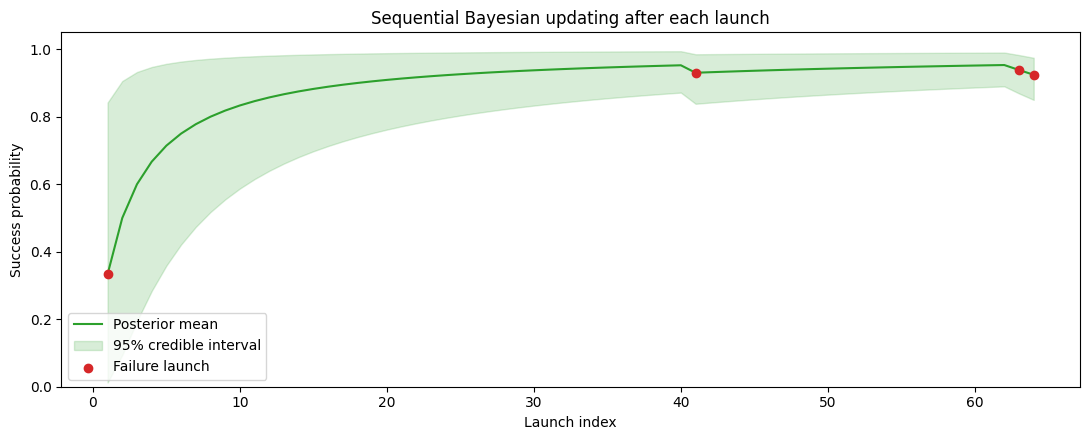

Saved sequential Bayesian update table and figure.


In [21]:
# Sequential Bayesian updating: update the reliability estimate after every launch.
running_successes = data['success'].astype(int).cumsum()
running_failures = (1 - data['success'].astype(int)).cumsum()
sequential_alpha = 1 + running_successes
sequential_beta = 1 + running_failures
sequential_update = data[['launch_index', 'mission', 'calendar_date', 'success']].copy()
sequential_update['posterior_alpha'] = sequential_alpha
sequential_update['posterior_beta'] = sequential_beta
sequential_update['posterior_mean'] = sequential_alpha / (sequential_alpha + sequential_beta)
sequential_update['lower_95'] = beta.ppf(0.025, sequential_alpha, sequential_beta)
sequential_update['upper_95'] = beta.ppf(0.975, sequential_alpha, sequential_beta)
display(sequential_update.tail(10))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sequential_update['launch_index'], sequential_update['posterior_mean'], color='tab:green', label='Posterior mean')
ax.fill_between(sequential_update['launch_index'], sequential_update['lower_95'], sequential_update['upper_95'], color='tab:green', alpha=0.18, label='95% credible interval')
failure_rows = sequential_update[sequential_update['success'] == 0]
ax.scatter(failure_rows['launch_index'], failure_rows['posterior_mean'], color='tab:red', zorder=3, label='Failure launch')
ax.set(xlabel='Launch index', ylabel='Success probability', title='Sequential Bayesian updating after each launch')
ax.set_ylim(0, 1.05); ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_09_sequential_bayesian_update.png', dpi=180); plt.show()
sequential_update.to_csv(RESULTS_DIR / 'sequential_bayesian_update.csv', index=False)
print('Saved sequential Bayesian update table and figure.')


## Step 3 interpretation

This baseline estimates overall mission-success probability under one constant `p`. A high posterior reliability does not prove that the final two failures are irrelevant, because a later change in reliability could be hidden by the long historical record. That question belongs to Step 4.